# unsupervised models

# Clustering Model Training
### K-Means, DBSCAN, HDBSCAN, and GMM clustering models.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score


## 2. Load Preprocessed Data


In [5]:
import pandas as pd

df_scaled = pd.read_csv("processed/final_clustering_ready.csv")

print(df_scaled.shape)
df_scaled.head()


(998, 43)


,Age_in_years,Age_in_months,Body_length,Weight,Owner_play_time_minutes,Sleep_time_hours,Breed_maine coon,Breed_nan,Breed_ragdoll,Gender_male,...,Preferred_food_nan,Preferred_food_wet,Country_france,Country_germany,Country_my country,Country_nan,Country_uk,Country_usa,Country_where i live,Country_with me
0,-1.716630,-1.726915,-1.711421,-1.567151,2.143177,0.019883,-0.568865,-0.342901,-0.805969,-0.913542,...,-0.14661,0.674396,3.013438,-0.293194,-0.03167,-0.268264,-0.33924,-1.168302,-0.03167,-0.03167
1,-1.686586,-1.695671,-1.711421,-1.325950,2.329459,0.019883,-0.568865,-0.342901,-0.805969,1.094641,...,-0.14661,0.674396,3.013438,-0.293194,-0.03167,-0.268264,-0.33924,-1.168302,-0.03167,-0.03167
2,-1.622743,0.022697,-1.635672,-1.181229,1.677472,-1.888149,-0.568865,-0.342901,-0.805969,-0.913542,...,-0.14661,0.674396,3.013438,-0.293194,-0.03167,-0.268264,-0.33924,-1.168302,-0.03167,-0.03167
3,-1.622743,0.022697,-1.559923,-1.084749,0.094074,-3.032968,-0.568865,-0.342901,-0.805969,-0.913542,...,-0.14661,0.674396,3.013438,-0.293194,-0.03167,-0.268264,-0.33924,-1.168302,-0.03167,-0.03167
4,-1.622743,0.022697,-1.559923,-1.084749,2.608882,-2.269755,-0.568865,-0.342901,-0.805969,-0.913542,...,-0.14661,0.674396,3.013438,-0.293194,-0.03167,-0.268264,-0.33924,-1.168302,-0.03167,-0.03167


In [6]:
print("df_scaled" in globals())
print(globals().keys())


True
dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'os', 'plt', 'sns', 'StandardScaler', 'PCA', 'KMeans', 'DBSCAN', 'AgglomerativeClustering', 'silhouette_score', '_i2', 'df', '_i3', '_i4', 'df_scaled', '_4', '_i5', '_5', '_i6'])


## 3. Dimensionality Reduction (PCA)

In [10]:
from sklearn.decomposition import PCA

pca_5 = PCA(n_components=5, random_state=42)
df_pca_5 = pca_5.fit_transform(df_scaled)



print("Original shape:", df.shape)
print("PCA shape:", df_pca.shape)

Original shape: (910, 43)
PCA shape: (910, 26)


## 3. find optimal k



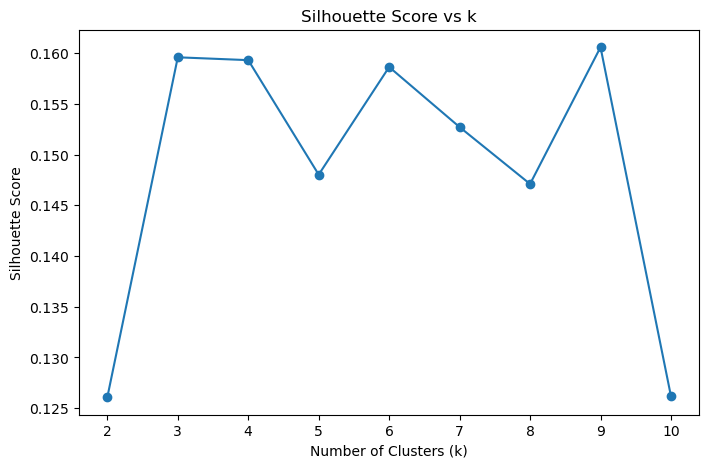

Best k based on Silhouette Score: 9
Best Silhouette Score: 0.16059006580507884


In [11]:
from sklearn.metrics import silhouette_score


silhouette_scores = []
K_range = range(2, 11)


for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(df_pca)
  score = silhouette_score(df_pca, labels)
  silhouette_scores.append(score)


plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()


best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print("Best k based on Silhouette Score:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

In [12]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans.fit_predict(df_pca)


kmeans_silhouette = silhouette_score(df_pca, kmeans_labels)
print("Final KMeans Silhouette Score:", kmeans_silhouette)

Final KMeans Silhouette Score: 0.16059006580507884


In [13]:
comparison = []
for k in [3, 4, best_k]:
  kmeans_tmp = KMeans(n_clusters=k, random_state=42)
  labels_tmp = kmeans_tmp.fit_predict(df_pca)
  score_tmp = silhouette_score(df_pca, labels_tmp)
  comparison.append({"k": k, "Silhouette Score": score_tmp})


comparison_df = pd.DataFrame(comparison)
comparison_df

,k,Silhouette Score
0,3,0.159597
1,4,0.159316
2,9,0.160590


In [17]:
# Select smaller k for better generalization and interpretability
final_k = 3


kmeans_final = KMeans(n_clusters=final_k, random_state=42)
final_labels = kmeans_final.fit_predict(df_pca)


final_silhouette = silhouette_score(df_pca, final_labels)
print("Final chosen k:", final_k)
print("Final Silhouette Score:", final_silhouette)

Final chosen k: 3
Final Silhouette Score: 0.1595965883152459


## 4. Visualization


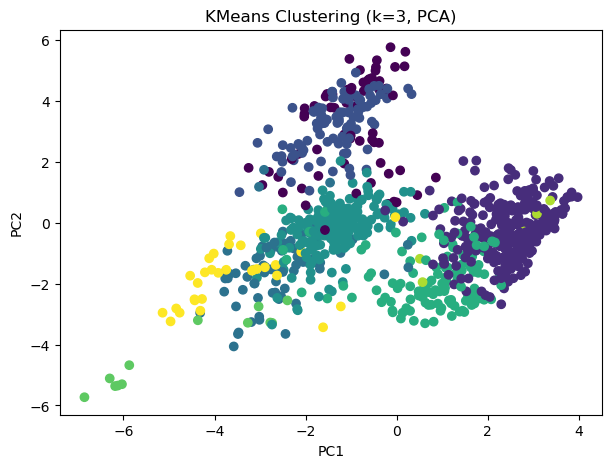

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(df_pca[:,0], df_pca[:,1], c=kmeans_labels)
plt.title(f"KMeans Clustering (k={final_k}, PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 5. DBSCAN Clustering

In [19]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_pca)


# Remove noise points (-1) for silhouette calculation
mask = dbscan_labels != -1


if len(set(dbscan_labels[mask])) > 1:
  dbscan_silhouette = silhouette_score(df_pca[mask], dbscan_labels[mask])
  print("DBSCAN Silhouette Score:", dbscan_silhouette)
else:
  print("DBSCAN produced only one cluster or noise")

DBSCAN produced only one cluster or noise


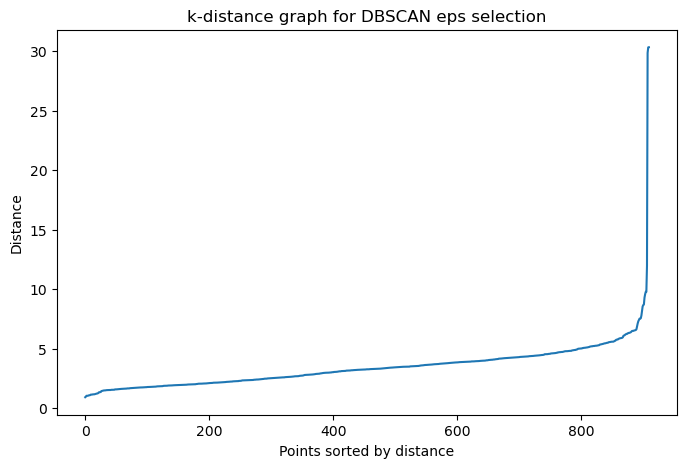

In [20]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(df_pca)
distances, indices = neighbors_fit.kneighbors(df_pca)

distances = np.sort(distances[:,4])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("k-distance graph for DBSCAN eps selection")
plt.ylabel("Distance")
plt.xlabel("Points sorted by distance")
plt.show()


The k-distance graph shows no clear elbow point, indicating the absence of distinct density-based clusters. Consequently, DBSCAN is not suitable for this dataset.

In [21]:
dbscan = DBSCAN(eps=6, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_pca)


# Remove noise points (-1) for silhouette calculation
mask = dbscan_labels != -1


if len(set(dbscan_labels[mask])) > 1:
  dbscan_silhouette = silhouette_score(df_pca[mask], dbscan_labels[mask])
  print("DBSCAN Silhouette Score:", dbscan_silhouette)
else:
  print("DBSCAN produced only one cluster or noise")

DBSCAN Silhouette Score: 0.30733271512014493


In [22]:
import numpy as np
np.unique(dbscan_labels, return_counts=True)


(array([-1,  0,  1,  2,  3]), array([ 25, 863,   7,  10,   5]))

DBSCAN produced one dominant cluster containing more than 95% of the data, with several very small clusters and noise points. This indicates over-smoothing rather than meaningful density-based clustering. Therefore, DBSCAN was not selected as a final model.


## 5. Visualization


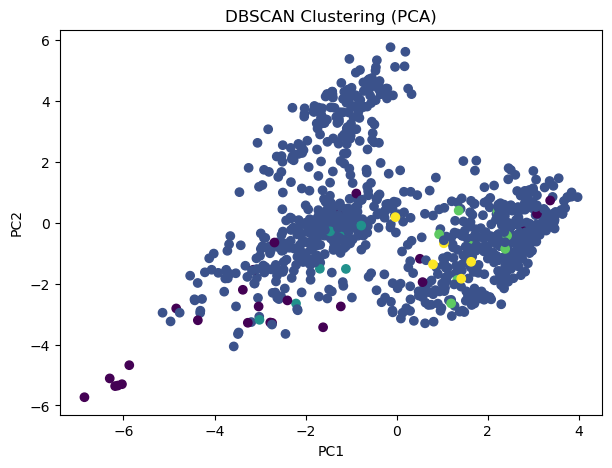

In [23]:
plt.figure(figsize=(7,5))
plt.scatter(df_pca[:,0], df_pca[:,1], c=dbscan_labels)
plt.title("DBSCAN Clustering (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 6. Agglomerative Clustering

In [24]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score


results_agg = []


for linkage in ['average', 'complete']:
  for k in [2, 3, 4]:
    agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = agg.fit_predict(df_pca_5)
    score = silhouette_score(df_pca_5, labels)
    results_agg.append({
    'Linkage': linkage,
    'k': k,
    'Silhouette Score': score
})


agg_results_df = pd.DataFrame(results_agg)
agg_results_df

,Linkage,k,Silhouette Score
0,average,2,0.465233
1,average,3,0.412852
2,average,4,0.289523
3,complete,2,0.538338
4,complete,3,0.328393
5,complete,4,0.289044


In [27]:
# Final choice based on best trade-off between score and interpretability
agg_final = AgglomerativeClustering(n_clusters=3, linkage='average')
agg_labels = agg_final.fit_predict(df_pca_5)


agg_silhouette = silhouette_score(df_pca_5, agg_labels)
print("Final Agglomerative Silhouette Score:", agg_silhouette)

Final Agglomerative Silhouette Score: 0.412851927735064


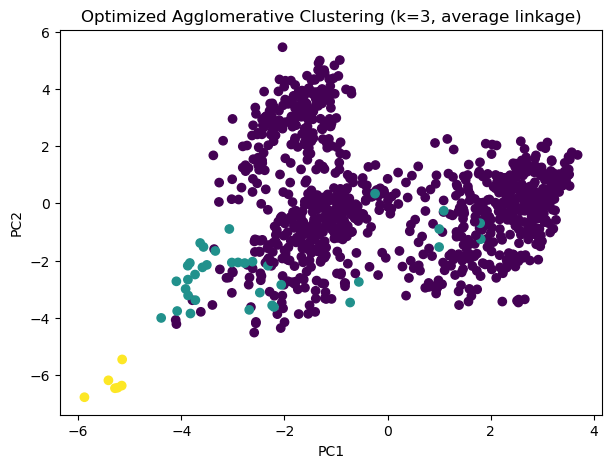

In [28]:
plt.figure(figsize=(7,5))
plt.scatter(df_pca_5[:,0], df_pca_5[:,1], c=agg_labels)
plt.title("Optimized Agglomerative Clustering (k=3, average linkage)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [24]:
# Save cluster labels
pd.DataFrame({'Cluster': cluster_labels}).to_csv('data/processed/kmeans_cluster_labels.csv', index=False)
print("Labels saved: data/processed/kmeans_cluster_labels.csv")

Labels saved: data/processed/kmeans_cluster_labels.csv


In [25]:
# Save data with clusters
df['Cluster'] = cluster_labels
df.to_csv('data/processed/clustered_data.csv', index=False)
print("Clustered data saved: data/processed/clustered_data.csv")


Clustered data saved: data/processed/clustered_data.csv


In [49]:
# Save data with clusters
df_hdbscan = df.copy()
cluster_col = 'HDBSCAN_Cluster' if HDBSCAN_AVAILABLE else 'Agglomerative_Cluster'
df_hdbscan[cluster_col] = hdbscan_labels
data_file = 'hdbscan_clustered_data.csv' if HDBSCAN_AVAILABLE else 'agglomerative_clustered_data.csv'
df_hdbscan.to_csv(f'data/processed/{data_file}', index=False)
print(f"Clustered data saved: data/processed/{data_file}")


Clustered data saved: data/processed/agglomerative_clustered_data.csv


## Gaussian Mixture Model (GMM) Clustering


### 10. Find Optimal Number of Components


In [41]:
# Test different numbers of components
n_components_range = range(2, 9)
gmm_scores = []
aic_scores = []
bic_scores = []

print("Testing different numbers of components...")
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=10)
    gmm.fit(X)
    labels = gmm.predict(X)
    
    # Calculate metrics
    score = silhouette_score(X, labels)
    aic = gmm.aic(X)
    bic = gmm.bic(X)
    
    gmm_scores.append(score)
    aic_scores.append(aic)
    bic_scores.append(bic)
    
    print(f"n_components={n}: Silhouette={score:.3f}, AIC={aic:.2f}, BIC={bic:.2f}")

# Find optimal number of components (highest silhouette score)
optimal_n_components = n_components_range[np.argmax(gmm_scores)]
print(f"\nOptimal n_components = {optimal_n_components}")


Testing different numbers of components...
n_components=2: Silhouette=0.154, AIC=-15920460.74, BIC=-15583072.66
n_components=3: Silhouette=0.084, AIC=-19064971.30, BIC=-18558885.50
n_components=4: Silhouette=0.017, AIC=-21605748.41, BIC=-20930964.91
n_components=5: Silhouette=0.010, AIC=-22419270.81, BIC=-21575789.60
n_components=6: Silhouette=0.006, AIC=-23412719.09, BIC=-22400540.17
n_components=7: Silhouette=0.004, AIC=-22717086.76, BIC=-21536210.13
n_components=8: Silhouette=0.007, AIC=-24192316.19, BIC=-22842741.85

Optimal n_components = 2


### 11. Train GMM Model


In [42]:
# Train GMM with optimal number of components
gmm_model = GaussianMixture(n_components=optimal_n_components, random_state=42, n_init=10)
gmm_model.fit(X)

# Get cluster labels
gmm_labels = gmm_model.predict(X)

print(f"GMM Model trained")
print(f"Number of components: {optimal_n_components}")
print(f"Silhouette Score: {silhouette_score(X, gmm_labels):.3f}")
print(f"AIC: {gmm_model.aic(X):.2f}")
print(f"BIC: {gmm_model.bic(X):.2f}")
print(f"\nCluster distribution:")
print(pd.Series(gmm_labels).value_counts().sort_index())


GMM Model trained
Number of components: 2
Silhouette Score: 0.154
AIC: -15920460.74
BIC: -15583072.66

Cluster distribution:
0    4178
1    7128
Name: count, dtype: int64


### 12. Save GMM Results


In [43]:
# Save GMM model
joblib.dump(gmm_model, 'models/gmm_model.pkl')
print("GMM model saved: models/gmm_model.pkl")





GMM model saved: models/gmm_model.pkl


In [44]:
# Save GMM cluster labels
pd.DataFrame({'Cluster': gmm_labels}).to_csv('data/processed/gmm_cluster_labels.csv', index=False)
print("GMM labels saved: data/processed/gmm_cluster_labels.csv")



GMM labels saved: data/processed/gmm_cluster_labels.csv


In [45]:
# Save data with GMM clusters
df_gmm = df.copy()
df_gmm['GMM_Cluster'] = gmm_labels
df_gmm.to_csv('data/processed/gmm_clustered_data.csv', index=False)
print("GMM clustered data saved: data/processed/gmm_clustered_data.csv")

GMM clustered data saved: data/processed/gmm_clustered_data.csv


# Evaluation K-Means


In [52]:
silhouette_kmeans = silhouette_score(X, cluster_labels)
print(f"K-Means Silhouette Score: {silhouette_kmeans:.3f}")



K-Means Silhouette Score: 0.207


# Evaluation DBSCAN


In [53]:
if len(set(dbscan_labels)) > 1 :
    silhouette_dbscan = silhouette_score(X, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {silhouette_dbscan:.3f}")

DBSCAN Silhouette Score: -0.062


# Evaluation GMM

In [54]:
silhouette_gmm = silhouette_score(X, gmm_labels)
print(f"GMM Silhouette Score: {silhouette_gmm:.3f}")
print(f"GMM AIC: {gmm_model.aic(X):.2f}, BIC: {gmm_model.bic(X):.2f}")

GMM Silhouette Score: 0.154
GMM AIC: -15920460.74, BIC: -15583072.66


## Evaluation HDBSCAN / Agglomerative


In [55]:
silhouette_hdbscan = silhouette_score(X, hdbscan_labels)
print(f"HDBSCAN / Agglomerative Silhouette Score: {silhouette_hdbscan:.3f}")

HDBSCAN / Agglomerative Silhouette Score: 0.175


## Comparison

In [56]:
# DataFrame
evaluation_df = pd.DataFrame({
    'Model': ['K-Means', 'DBSCAN', 'GMM', 'HDBSCAN/Agglomerative'],
    'Silhouette': [silhouette_kmeans, silhouette_dbscan, silhouette_gmm, silhouette_hdbscan],
    'AIC': [None, None, gmm_model.aic(X), None],
    'BIC': [None, None, gmm_model.bic(X), None]
})

print("\nModel Comparison:")
print(evaluation_df)

# Silhouette
best_model = evaluation_df.loc[evaluation_df['Silhouette'].idxmax(), 'Model']
print(f"\nBest Model based on Silhouette Score: {best_model}")



Model Comparison:
                   Model  Silhouette           AIC           BIC
0                K-Means    0.206942           NaN           NaN
1                 DBSCAN   -0.062280           NaN           NaN
2                    GMM    0.153777 -1.592046e+07 -1.558307e+07
3  HDBSCAN/Agglomerative    0.174802           NaN           NaN

Best Model based on Silhouette Score: K-Means


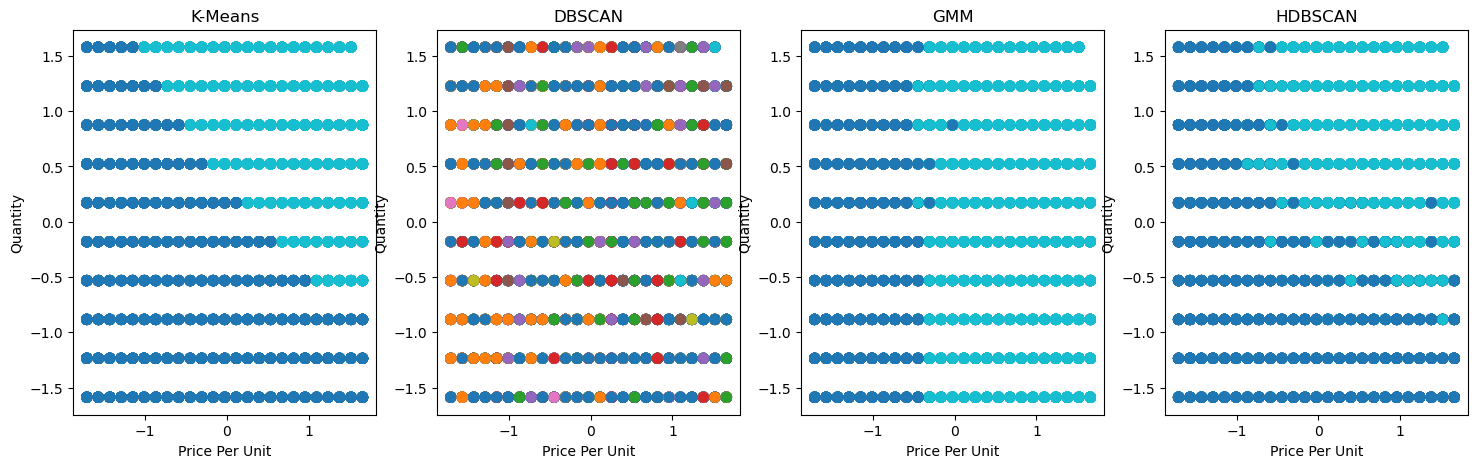

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18,5))

models = [('K-Means', cluster_labels),
          ('DBSCAN', dbscan_labels),
          ('GMM', gmm_labels),
          ('HDBSCAN', hdbscan_labels)]

for ax, (name, labels) in zip(axes, models):
    scatter = ax.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap='tab10', s=50)
    ax.set_title(name)
    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])

plt.show()
